# Power Savings Analysis - X-Wing Platform

This notebook analyzes power consumption and efficiency gains for the X-wing platform using three approaches:

1. **Cubic hover model** ($P \propto \Omega^3$) - Upper bound assuming hover conditions
2. **Forward-flight momentum theory** - Accounts for edgewise induced flow
3. **Including parasitic power** - Total power = induced + parasitic

The goal is to demonstrate that the cubic hover model overestimates power savings because it doesn't account for:
- Reduced induced power in forward flight
- Increased parasitic power from drag
- Wing lift contribution

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# Configure matplotlib for better plots
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

## 1. Platform Parameters and Constants

In [2]:
# Platform parameters
MASS = 2.5  # kg
GRAVITY = 9.81  # m/s²
WEIGHT = MASS * GRAVITY  # N

# Rotor parameters
PROP_DIAMETER = 7 * 0.0254  # 7 inches to meters
ROTOR_RADIUS = PROP_DIAMETER / 2  # m
NUM_ROTORS = 4
DISK_AREA = np.pi * ROTOR_RADIUS**2  # Single rotor disk area, m²

# Air properties
RHO = 1.225  # kg/m³ (sea level)

# Thrust map coefficients: T = k_t * RPM² + b_t * RPM
K_T = 5.15e-8  # N/(RPM²)
B_T = -0.09e-3  # N/RPM

# Hover baseline
HOVER_RPM = 12000  # RPM per motor

print(f"Platform Configuration:")
print(f"  Mass: {MASS} kg")
print(f"  Weight: {WEIGHT:.2f} N")
print(f"  Propeller: {PROP_DIAMETER*1000:.1f} mm diameter")
print(f"  Number of rotors: {NUM_ROTORS}")
print(f"  Total disk area: {NUM_ROTORS * DISK_AREA:.4f} m²")
print(f"  Hover RPM: {HOVER_RPM} per motor")

Platform Configuration:
  Mass: 2.5 kg
  Weight: 24.53 N
  Propeller: 177.8 mm diameter
  Number of rotors: 4
  Total disk area: 0.0993 m²
  Hover RPM: 12000 per motor


## 2. Flight Test Data

Straight-line flight tests with NACA 0015 wings:
- **Speed**: Forward airspeed [m/s]
- **Pitch**: Pitch angle from horizontal plane [degrees] (0° = horizontal, 90° = vertical)
- **RPM**: Per-motor rotation speed [rpm]

In [3]:
# Flight test data: [speed (m/s), pitch_angle (deg), motor_rpm (RPM)]
flight_data = np.array([
    [9.14,  37.2, 11300], 
    [10.67, 28.5, 11100],
    [11.4,  22.3, 10500],
    [13.6,  16.3, 9970],  
])

# Create DataFrame for easier manipulation
df_raw = pd.DataFrame(flight_data, columns=['speed', 'pitch', 'rpm'])
print("Flight Test Data:")
print(df_raw.to_string(index=False))

Flight Test Data:
 speed  pitch     rpm
  9.14   37.2 11300.0
 10.67   28.5 11100.0
 11.40   22.3 10500.0
 13.60   16.3  9970.0


## 3. Core Functions

### Thrust Model
From bench tests: $T = k_t \cdot \text{RPM}^2 + b_t \cdot \text{RPM}$

In [4]:
def thrust_from_rpm(rpm):
    """Calculate thrust per motor from RPM using fitted map."""
    return K_T * rpm**2 + B_T * rpm

def total_rotor_thrust(rpm_per_motor):
    """Calculate total thrust from all rotors."""
    return NUM_ROTORS * thrust_from_rpm(rpm_per_motor)

# Test the thrust model
test_rpms = np.array([800, 1000, 1200, 1400, 1600])
test_thrusts = [thrust_from_rpm(rpm) for rpm in test_rpms]

print("Thrust Model Verification:")
for rpm, thrust in zip(test_rpms, test_thrusts):
    print(f"  {rpm} RPM → {thrust:.2f} N per motor → {NUM_ROTORS*thrust:.2f} N total")

Thrust Model Verification:
  800 RPM → -0.04 N per motor → -0.16 N total
  1000 RPM → -0.04 N per motor → -0.15 N total
  1200 RPM → -0.03 N per motor → -0.14 N total
  1400 RPM → -0.03 N per motor → -0.10 N total
  1600 RPM → -0.01 N per motor → -0.05 N total


### Motor Power Model
From motor datasheet: Measure power consumption at different RPM values

In [ ]:
# Motor power data from datasheet: [RPM, Power (W)]
# TODO: Replace with your actual motor datasheet values
motor_power_data = np.array([
    [0,    0],      # Zero RPM, zero power
    [3000, 10],     # Example: 3000 RPM → 10W (REPLACE WITH REAL DATA)
    [6000, 35],     # Example: 6000 RPM → 35W (REPLACE WITH REAL DATA)
    [9000, 75],     # Example: 9000 RPM → 75W (REPLACE WITH REAL DATA)
    [12000, 130],   # Example: 12000 RPM → 130W (REPLACE WITH REAL DATA)
    [15000, 200],   # Example: 15000 RPM → 200W (REPLACE WITH REAL DATA)
])

# Extract RPM and Power columns
rpm_data = motor_power_data[:, 0]
power_data = motor_power_data[:, 1]

# Fit polynomial (try quadratic and cubic)
# Power typically scales as P ∝ RPM³ for propellers (momentum theory)
# But motor+prop system may differ, so we'll fit and compare

# Quadratic fit: P = a*RPM² + b*RPM + c
coeffs_quad = np.polyfit(rpm_data, power_data, 2)
power_fit_quad = np.poly1d(coeffs_quad)

# Cubic fit: P = a*RPM³ + b*RPM² + c*RPM + d
coeffs_cubic = np.polyfit(rpm_data, power_data, 3)
power_fit_cubic = np.poly1d(coeffs_cubic)

# Generate smooth curve for plotting
rpm_smooth = np.linspace(0, rpm_data.max() * 1.1, 200)
power_quad_smooth = power_fit_quad(rpm_smooth)
power_cubic_smooth = power_fit_cubic(rpm_smooth)

# Calculate R² for both fits
from sklearn.metrics import r2_score
r2_quad = r2_score(power_data, power_fit_quad(rpm_data))
r2_cubic = r2_score(power_data, power_fit_cubic(rpm_data))

# Plot the data and fits
fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(rpm_data, power_data, 'o', markersize=10, label='Datasheet values', color='black', zorder=3)
ax.plot(rpm_smooth, power_quad_smooth, '--', linewidth=2, 
        label=f'Quadratic fit (R²={r2_quad:.4f})', color='blue')
ax.plot(rpm_smooth, power_cubic_smooth, '-', linewidth=2, 
        label=f'Cubic fit (R²={r2_cubic:.4f})', color='red')

ax.set_xlabel('Motor RPM [rev/min]', fontsize=12)
ax.set_ylabel('Electrical Power [W]', fontsize=12)
ax.set_title('Motor Power Consumption vs RPM', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)

plt.tight_layout()
plt.savefig('../data/motor_power_fit.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\\nQuadratic fit: P = {coeffs_quad[0]:.2e}*RPM² + {coeffs_quad[1]:.2e}*RPM + {coeffs_quad[2]:.2f}")
print(f"  R² = {r2_quad:.4f}")
print(f"\\nCubic fit: P = {coeffs_cubic[0]:.2e}*RPM³ + {coeffs_cubic[1]:.2e}*RPM² + {coeffs_cubic[2]:.2e}*RPM + {coeffs_cubic[3]:.2f}")
print(f"  R² = {r2_cubic:.4f}")

# Choose the best fit based on R²
if r2_cubic > r2_quad:
    print(f"\\nCubic fit is better (R² difference: {r2_cubic - r2_quad:.4f})")
    power_from_rpm = power_fit_cubic
    power_coeffs = coeffs_cubic
    fit_type = 'cubic'
else:
    print(f"\\nQuadratic fit is sufficient (R² difference: {r2_quad - r2_cubic:.4f})")
    power_from_rpm = power_fit_quad
    power_coeffs = coeffs_quad
    fit_type = 'quadratic'

print(f"\\nUsing {fit_type} fit for power estimation.")

### Forward-Flight Induced Velocity

From momentum theory for edgewise flow:

$$v_i = \frac{V}{2} \left( \sqrt{1 + \frac{2T}{\rho A V^2}} - 1 \right)$$

where $A$ is the total rotor disk area.

In [5]:
def induced_velocity_forward_flight(thrust_total, airspeed):
    """
    Edgewise (forward flight) induced velocity from momentum theory.
    
    v_i = (V/2) * (sqrt(1 + 2*T/(rho*A*V²)) - 1)
    """
    A_total = NUM_ROTORS * DISK_AREA
    
    # Avoid division by zero - fall back to hover
    if airspeed < 0.1:
        return np.sqrt(thrust_total / (2 * RHO * A_total))
    
    # Forward flight formula
    term = 1 + 2 * thrust_total / (RHO * A_total * airspeed**2)
    v_i = (airspeed / 2) * (np.sqrt(term) - 1)
    
    return v_i

def induced_velocity_hover(thrust_total):
    """Hover induced velocity: v_i = sqrt(T / (2*rho*A))"""
    A_total = NUM_ROTORS * DISK_AREA
    return np.sqrt(thrust_total / (2 * RHO * A_total))

## 4. Power Component Analysis

For each flight condition, we compute:

1. **Vertical thrust fraction**: $v = \sin(\theta_{\text{horiz}})$
2. **Wing lift fraction**: $L_{\text{wing}}/W = 1 - (T_{\text{rot}}/W) \cdot v$
3. **Total drag**: $D_{\text{tot}} = T_{\text{rot}} \sqrt{1 - v^2}$ (horizontal thrust component)
4. **Induced power**: $P_{\text{ind}} = T_{\text{rot}} \cdot v_i$
5. **Parasitic power**: $P_{\text{par}} = D_{\text{tot}} \cdot V$

In [6]:
def compute_power_components(rpm, pitch_deg, airspeed):
    """
    Compute all power components for a given flight condition.
    
    Returns dict with:
        - T_rot: Total rotor thrust (N)
        - v_factor: Vertical thrust fraction
        - L_wing_frac: Wing lift as fraction of weight
        - D_tot: Total drag (N)
        - v_i: Induced velocity (m/s)
        - P_ind: Induced power (W)
        - P_par: Parasitic power (W)
        - P_total: Total power estimate (W)
    """
    # Convert pitch to radians
    pitch_rad = np.deg2rad(pitch_deg)
    
    # Total rotor thrust
    T_rot = total_rotor_thrust(rpm)
    
    # Vertical component factor (sin for pitch from horizontal)
    v_factor = np.sin(pitch_rad)
    
    # Wing lift fraction: L_wing/W = 1 - (T_rot/W)*v
    L_wing_frac = 1 - (T_rot / WEIGHT) * v_factor
    
    # Horizontal rotor component (balances drag)
    D_tot = T_rot * np.sqrt(1 - v_factor**2)
    
    # Forward-flight induced velocity
    v_i = induced_velocity_forward_flight(T_rot, airspeed)
    
    # Induced power
    P_ind = T_rot * v_i
    
    # Parasitic power
    P_par = D_tot * airspeed
    
    # Total power estimate
    P_total = P_ind + P_par
    
    return {
        'T_rot': T_rot,
        'v_factor': v_factor,
        'L_wing_frac': L_wing_frac,
        'D_tot': D_tot,
        'v_i': v_i,
        'P_ind': P_ind,
        'P_par': P_par,
        'P_total': P_total
    }

## 5. Hover Baseline Calculation

In [7]:
# Compute hover baseline
hover_thrust = total_rotor_thrust(HOVER_RPM)
hover_vi = induced_velocity_hover(hover_thrust)
hover_power = hover_thrust * hover_vi

print(f"Hover Baseline (RPM = {HOVER_RPM}):")
print(f"  Total thrust: {hover_thrust:.2f} N")
print(f"  Induced velocity: {hover_vi:.2f} m/s")
print(f"  Induced power: {hover_power:.1f} W")
print(f"  Thrust-to-weight ratio: {hover_thrust/WEIGHT:.3f}")

Hover Baseline (RPM = 12000):
  Total thrust: 25.34 N
  Induced velocity: 10.21 m/s
  Induced power: 258.7 W
  Thrust-to-weight ratio: 1.033


=== RPM → Power fit results (per motor) ===
            pure_cubic: R² = 0.9985, params = [9.049221e-11]
             power_law: R² = 0.9994, params = [2.071542e-11 3.147719e+00]
          cubic+linear: R² = 0.9990, params = [ 9.384874e-11 -1.495195e-03]
   cubic+linear+offset: R² = 0.9996, params = [ 1.014039e-10 -8.219866e-03  6.758086e+01]

Selected model: cubic+linear+offset (R²=0.9996)


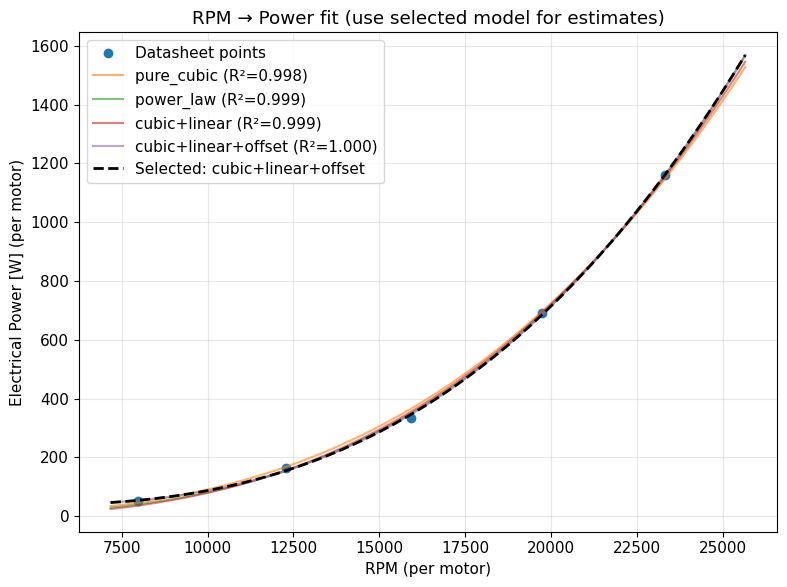

RPM 11300: P_motor=121.0 W, P_total=484.0 W
RPM 12000: P_motor=144.2 W, P_total=576.7 W
RPM 11100: P_motor=115.0 W, P_total=460.1 W
RPM 10500: P_motor=98.7 W, P_total=394.6 W
RPM 9970: P_motor=86.1 W, P_total=344.5 W


In [17]:
# --- RPM → Power (W) fit from datasheet points ---
# Paste your datapoints here (per motor). Use ELECTRICAL power from the datasheet (Watts).
# Example placeholders — REPLACE with your values:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

rpm_data = np.array([7976.2, 12280.6, 15926.2, 19724.3, 23321.9], dtype=float)   # RPM
pwr_data = np.array([51.1,   163.8,   333.8,   690.7,   1160.6], dtype=float)  # Watts

assert rpm_data.shape == pwr_data.shape and rpm_data.ndim == 1, "rpm_data and pwr_data must be 1D and same length"
assert np.all(rpm_data > 0) and np.all(pwr_data > 0), "RPM and Power must be positive"

# ---- Candidate models ----
def pure_cubic(rpm, a3):
    return a3 * rpm**3

def cubic_plus_linear(rpm, a3, a1):
    return a3 * rpm**3 + a1 * rpm

def cubic_plus_linear_offset(rpm, a3, a1, a0):
    return a3 * rpm**3 + a1 * rpm + a0

def power_law(rpm, k, n):
    return k * rpm**n

models = {
    "pure_cubic": (pure_cubic, [1e-9]),
    "cubic+linear": (cubic_plus_linear, [1e-9, 1e-2]),
    "cubic+linear+offset": (cubic_plus_linear_offset, [1e-9, 1e-2, 0.0]),
    "power_law": (power_law, [1e-6, 3.0]),
}

# ---- Fit and score ----
def r2_score(y, yhat):
    ybar = np.mean(y)
    ss_res = np.sum((y - yhat)**2)
    ss_tot = np.sum((y - ybar)**2)
    return 1.0 - ss_res/ss_tot if ss_tot > 0 else np.nan

fit_results = {}
for name, (fn, p0) in models.items():
    try:
        popt, pcov = curve_fit(fn, rpm_data, pwr_data, p0=p0, maxfev=100000)
        yhat = fn(rpm_data, *popt)
        r2 = r2_score(pwr_data, yhat)
        fit_results[name] = {"fn": fn, "popt": popt, "r2": r2}
    except Exception as e:
        fit_results[name] = {"fn": fn, "popt": None, "r2": -np.inf}

# Pick the best model by R² (ties → prefer simpler)
order = ["pure_cubic", "power_law", "cubic+linear", "cubic+linear+offset"]
best_name = max(order, key=lambda n: fit_results[n]["r2"])
best = fit_results[best_name]
best_fn, best_popt, best_r2 = best["fn"], best["popt"], best["r2"]

print("=== RPM → Power fit results (per motor) ===")
for name in order:
    res = fit_results[name]
    if res["popt"] is not None:
        print(f"{name:>22s}: R² = {res['r2']:.4f}, params = {np.array2string(res['popt'], precision=6)}")
    else:
        print(f"{name:>22s}: fit failed")

print(f"\nSelected model: {best_name} (R²={best_r2:.4f})")

# Callable estimator
def power_from_rpm(rpm, model=best_name):
    """Return electrical power [W] per motor at given RPM (array or scalar)."""
    rpm = np.asarray(rpm, dtype=float)
    fn = fit_results[model]["fn"]
    popt = fit_results[model]["popt"]
    if popt is None:
        raise RuntimeError(f"Selected model '{model}' has no fit.")
    return fn(rpm, *popt)

# Quick sanity check & plot
rpm_grid = np.linspace(0.9*np.min(rpm_data), 1.1*np.max(rpm_data), 300)
plt.figure(figsize=(8,6))
plt.plot(rpm_data, pwr_data, "o", label="Datasheet points")
for name in order:
    res = fit_results[name]
    if res["popt"] is not None:
        plt.plot(rpm_grid, res["fn"](rpm_grid, *res["popt"]), "-", alpha=0.6, label=f"{name} (R²={res['r2']:.3f})")
plt.plot(rpm_grid, power_from_rpm(rpm_grid), "k--", lw=2, label=f"Selected: {best_name}")
plt.xlabel("RPM (per motor)")
plt.ylabel("Electrical Power [W] (per motor)")
plt.title("RPM → Power fit (use selected model for estimates)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# Example usage for your test cases (per motor and total across 4 motors)
example_rpms = np.array([11300, 12000, 11100, 10500, 9970], dtype=float)
p_motor = power_from_rpm(example_rpms)                # W per motor
p_total = 4.0 * p_motor                               # W total (4 motors)
for r, pm, pt in zip(example_rpms, p_motor, p_total):
    print(f"RPM {r:.0f}: P_motor={pm:.1f} W, P_total={pt:.1f} W")

# NOTE:
# - Datasheet power depends on voltage/prop/test stand; your in-flight power WILL differ.
# - Use this as an estimate and clearly label it as "datasheet-based" in the thesis.
# - Avoid extrapolating far beyond the rpm_data range; warn if you must.
if np.any((example_rpms < rpm_grid.min()) | (example_rpms > rpm_grid.max())):
    print("WARNING: Example RPMs extrapolate beyond the fit range.")


## 6. Process Flight Test Data

For each test point, calculate:
1. Cubic hover model savings (upper bound)
2. Forward-flight model savings (improved estimate)

In [8]:
results = []

for speed, pitch, rpm in flight_data:
    # Compute power components
    comp = compute_power_components(rpm, pitch, speed)
    
    # Method 1: Cubic hover approximation (upper bound)
    rpm_ratio = rpm / HOVER_RPM
    cubic_power_ratio = rpm_ratio**3
    savings_cubic = (1 - cubic_power_ratio) * 100
    
    # Method 2: Forward-flight momentum theory
    power_ratio_forward = comp['P_total'] / hover_power
    savings_forward = (1 - power_ratio_forward) * 100
    
    # Store results
    results.append({
        'speed': speed,
        'pitch': pitch,
        'rpm': rpm,
        'rpm_ratio': rpm_ratio,
        'T_rot': comp['T_rot'],
        'v_factor': comp['v_factor'],
        'L_wing_frac': comp['L_wing_frac'],
        'D_tot': comp['D_tot'],
        'v_i': comp['v_i'],
        'P_ind': comp['P_ind'],
        'P_par': comp['P_par'],
        'P_total': comp['P_total'],
        'cubic_power_ratio': cubic_power_ratio,
        'forward_power_ratio': power_ratio_forward,
        'savings_cubic': savings_cubic,
        'savings_forward': savings_forward,
        'overestimation': savings_cubic - savings_forward
    })

# Create results DataFrame
df = pd.DataFrame(results)

print("\n" + "="*80)
print("POWER ANALYSIS RESULTS")
print("="*80)
print("\nFlight Conditions:")
print(df[['speed', 'pitch', 'rpm', 'T_rot', 'L_wing_frac']].to_string(index=False))

print("\nPower Components:")
print(df[['speed', 'P_ind', 'P_par', 'P_total']].to_string(index=False))

print("\nPower Savings Comparison:")
print(df[['speed', 'savings_cubic', 'savings_forward', 'overestimation']].to_string(index=False))


POWER ANALYSIS RESULTS

Flight Conditions:
 speed  pitch     rpm     T_rot  L_wing_frac
  9.14   37.2 11300.0 22.236140     0.451827
 10.67   28.5 11100.0 21.385260     0.583928
 11.40   22.3 10500.0 18.931500     0.707088
 13.60   16.3  9970.0 16.887385     0.806739

Power Components:
 speed      P_ind      P_par    P_total
  9.14 133.990509 161.885402 295.875911
 10.67 116.584473 200.529125 317.113598
 11.40  90.911448 199.677929 290.589377
 13.60  66.768981 220.436985 287.205966

Power Savings Comparison:
 speed  savings_cubic  savings_forward  overestimation
  9.14      16.499016       -14.389616       30.888632
 10.67      20.854687       -22.600393       43.455080
 11.40      33.007812       -12.345771       45.353584
 13.60      42.648902       -11.037699       53.686601


## 7. Visualization

### 7.1 Power Savings Comparison

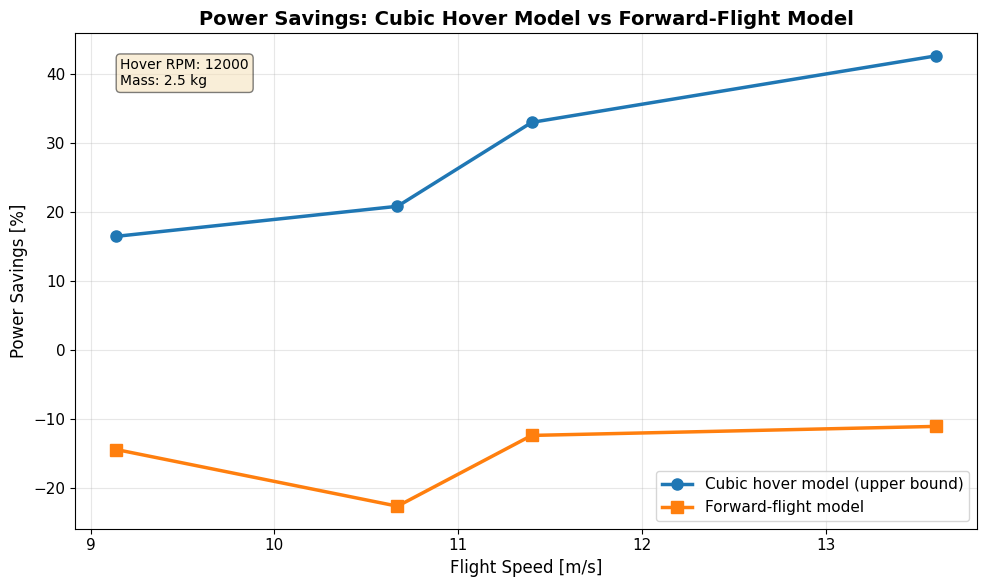


Key Observation: The cubic hover model overestimates savings by 
43.3 percentage points on average.


In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['speed'], df['savings_cubic'], 'o-', 
        label='Cubic hover model (upper bound)', linewidth=2.5, markersize=8)
ax.plot(df['speed'], df['savings_forward'], 's-', 
        label='Forward-flight model', linewidth=2.5, markersize=8)

ax.set_xlabel('Flight Speed [m/s]', fontsize=12)
ax.set_ylabel('Power Savings [%]', fontsize=12)
ax.set_title('Power Savings: Cubic Hover Model vs Forward-Flight Model', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Add text annotation
ax.text(0.05, 0.95, f'Hover RPM: {HOVER_RPM}\nMass: {MASS} kg', 
        transform=ax.transAxes, fontsize=10, verticalalignment='top',
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('../data/power_savings_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nKey Observation: The cubic hover model overestimates savings by ")
print(f"{df['overestimation'].mean():.1f} percentage points on average.")

### 7.2 Wing Lift Contribution

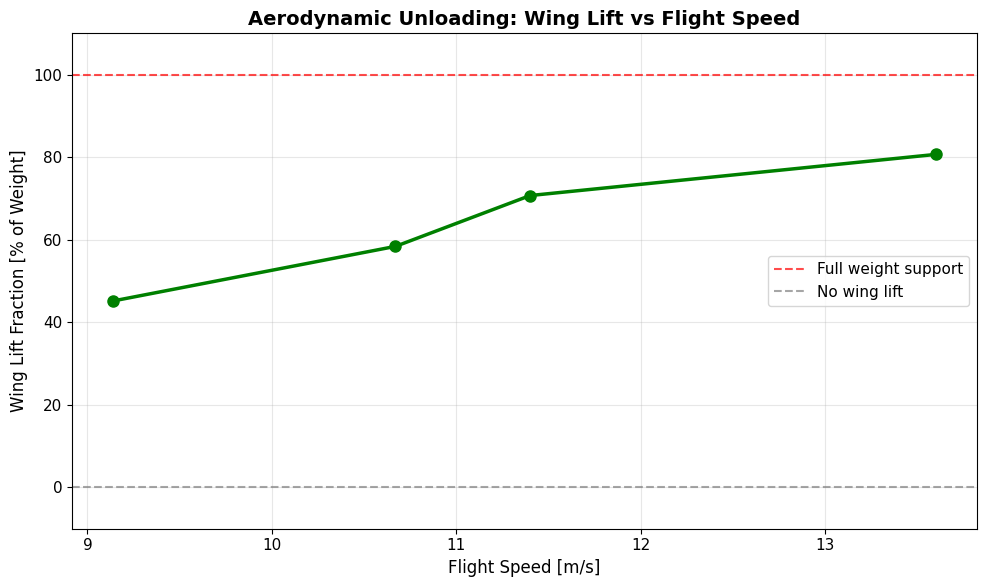


Wing lift increases from 45.2% at 9.1 m/s
to 80.7% at 13.6 m/s


In [10]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['speed'], df['L_wing_frac']*100, 'o-', 
        color='green', linewidth=2.5, markersize=8)

ax.axhline(y=100, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Full weight support')
ax.axhline(y=0, color='gray', linestyle='--', linewidth=1.5, alpha=0.7, label='No wing lift')

ax.set_xlabel('Flight Speed [m/s]', fontsize=12)
ax.set_ylabel('Wing Lift Fraction [% of Weight]', fontsize=12)
ax.set_title('Aerodynamic Unloading: Wing Lift vs Flight Speed', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
ax.set_ylim(-10, 110)

plt.tight_layout()
plt.savefig('../data/wing_lift_fraction.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nWing lift increases from {df['L_wing_frac'].iloc[0]*100:.1f}% at {df['speed'].iloc[0]:.1f} m/s")
print(f"to {df['L_wing_frac'].iloc[-1]*100:.1f}% at {df['speed'].iloc[-1]:.1f} m/s")

### 7.3 Power Component Breakdown

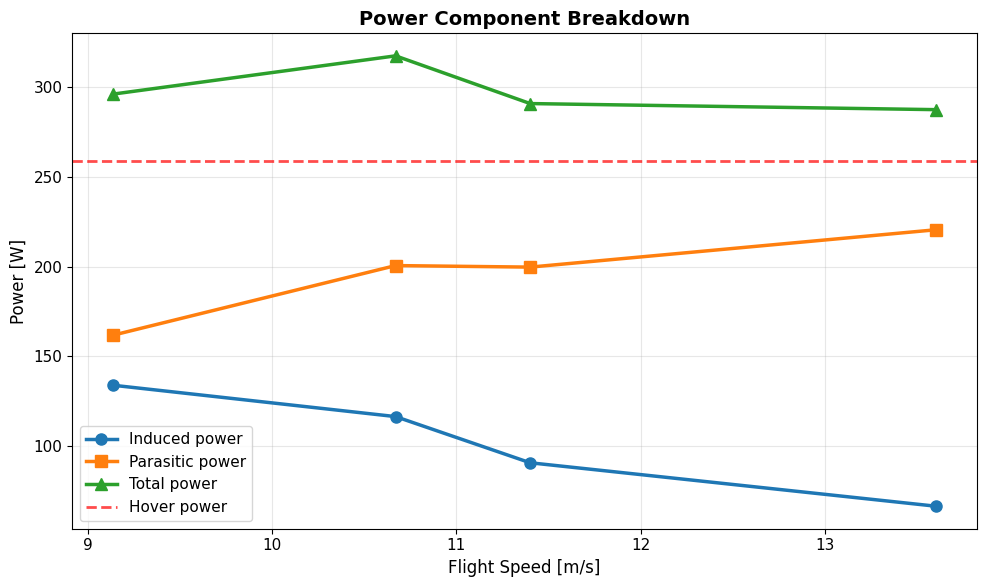


Observation: Induced power decreases but parasitic power increases with speed.
At 13.6 m/s: Induced = 66.8 W, Parasitic = 220.4 W


In [11]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['speed'], df['P_ind'], 'o-', label='Induced power', linewidth=2.5, markersize=8)
ax.plot(df['speed'], df['P_par'], 's-', label='Parasitic power', linewidth=2.5, markersize=8)
ax.plot(df['speed'], df['P_total'], '^-', label='Total power', linewidth=2.5, markersize=8)
ax.axhline(y=hover_power, color='red', linestyle='--', linewidth=2, alpha=0.7, label='Hover power')

ax.set_xlabel('Flight Speed [m/s]', fontsize=12)
ax.set_ylabel('Power [W]', fontsize=12)
ax.set_title('Power Component Breakdown', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/power_components.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nObservation: Induced power decreases but parasitic power increases with speed.")
print(f"At {df['speed'].iloc[-1]:.1f} m/s: Induced = {df['P_ind'].iloc[-1]:.1f} W, Parasitic = {df['P_par'].iloc[-1]:.1f} W")

### 7.4 Overestimation Error

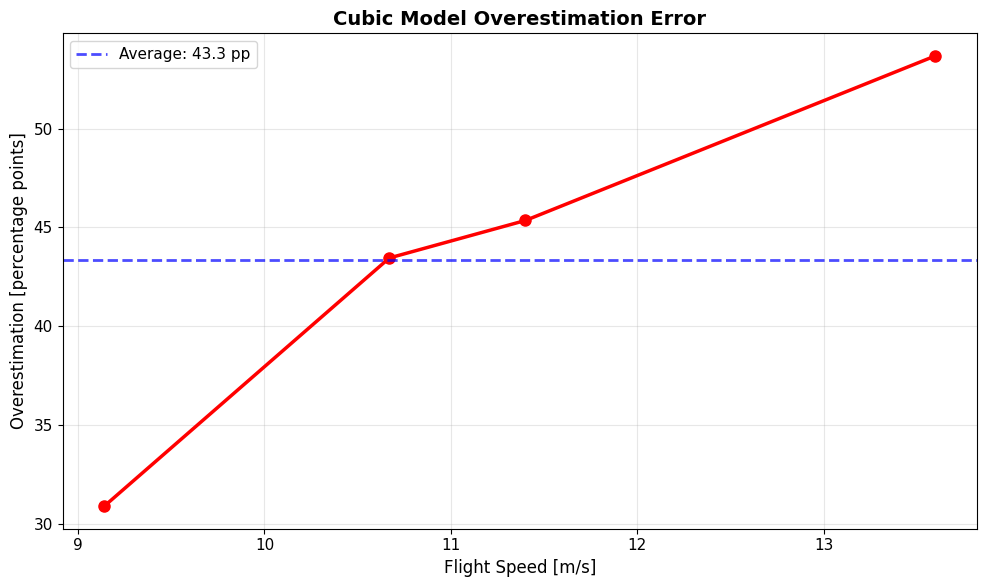


The cubic hover model overestimates power savings by:
  Minimum: 30.9 pp at 9.1 m/s
  Maximum: 53.7 pp at 13.6 m/s
  Average: 43.3 pp


In [12]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(df['speed'], df['overestimation'], 'o-', 
        color='red', linewidth=2.5, markersize=8)

ax.set_xlabel('Flight Speed [m/s]', fontsize=12)
ax.set_ylabel('Overestimation [percentage points]', fontsize=12)
ax.set_title('Cubic Model Overestimation Error', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Add average line
avg_error = df['overestimation'].mean()
ax.axhline(y=avg_error, color='blue', linestyle='--', linewidth=2, alpha=0.7, 
           label=f'Average: {avg_error:.1f} pp')
ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig('../data/overestimation_error.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nThe cubic hover model overestimates power savings by:")
print(f"  Minimum: {df['overestimation'].min():.1f} pp at {df.loc[df['overestimation'].idxmin(), 'speed']:.1f} m/s")
print(f"  Maximum: {df['overestimation'].max():.1f} pp at {df.loc[df['overestimation'].idxmax(), 'speed']:.1f} m/s")
print(f"  Average: {avg_error:.1f} pp")

### 7.5 Combined Summary Figure

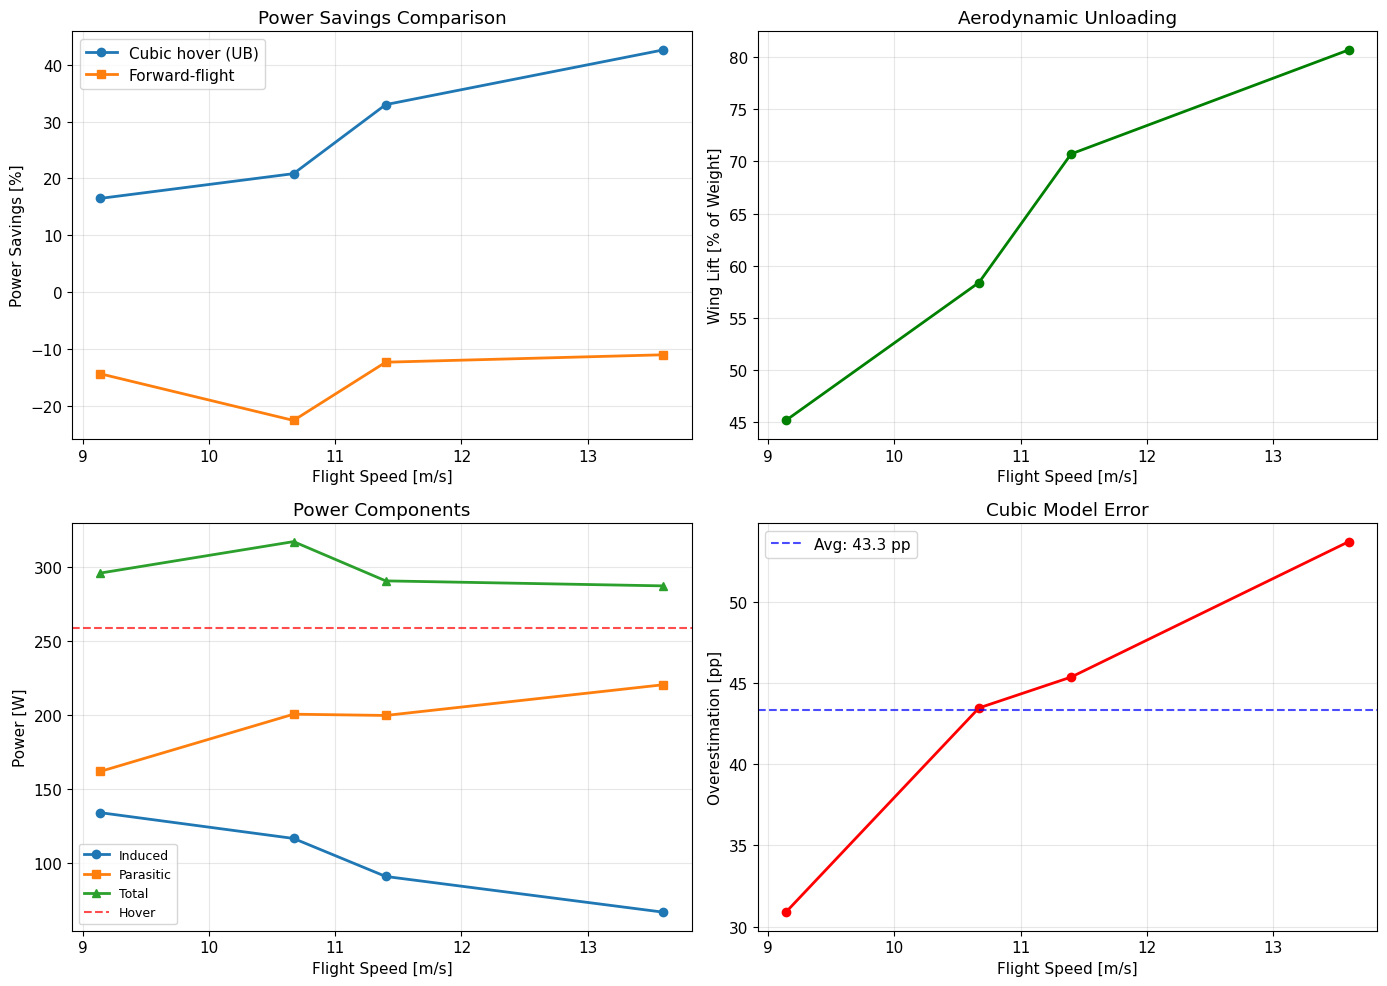

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Plot 1: Power savings comparison
ax = axes[0, 0]
ax.plot(df['speed'], df['savings_cubic'], 'o-', label='Cubic hover (UB)', linewidth=2)
ax.plot(df['speed'], df['savings_forward'], 's-', label='Forward-flight', linewidth=2)
ax.set_xlabel('Flight Speed [m/s]')
ax.set_ylabel('Power Savings [%]')
ax.set_title('Power Savings Comparison')
ax.legend()
ax.grid(True, alpha=0.3)

# Plot 2: Wing lift fraction
ax = axes[0, 1]
ax.plot(df['speed'], df['L_wing_frac']*100, 'o-', color='green', linewidth=2)
ax.set_xlabel('Flight Speed [m/s]')
ax.set_ylabel('Wing Lift [% of Weight]')
ax.set_title('Aerodynamic Unloading')
ax.grid(True, alpha=0.3)

# Plot 3: Power components
ax = axes[1, 0]
ax.plot(df['speed'], df['P_ind'], 'o-', label='Induced', linewidth=2)
ax.plot(df['speed'], df['P_par'], 's-', label='Parasitic', linewidth=2)
ax.plot(df['speed'], df['P_total'], '^-', label='Total', linewidth=2)
ax.axhline(y=hover_power, color='red', linestyle='--', linewidth=1.5, alpha=0.7, label='Hover')
ax.set_xlabel('Flight Speed [m/s]')
ax.set_ylabel('Power [W]')
ax.set_title('Power Components')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# Plot 4: Overestimation error
ax = axes[1, 1]
ax.plot(df['speed'], df['overestimation'], 'o-', color='red', linewidth=2)
ax.axhline(y=df['overestimation'].mean(), color='blue', linestyle='--', 
           linewidth=1.5, alpha=0.7, label=f"Avg: {df['overestimation'].mean():.1f} pp")
ax.set_xlabel('Flight Speed [m/s]')
ax.set_ylabel('Overestimation [pp]')
ax.set_title('Cubic Model Error')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../data/power_analysis_summary.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Save Results

In [14]:
# Save detailed results
output_file = '../data/power_savings_analysis.csv'
df.to_csv(output_file, index=False, float_format='%.4f')
print(f"Results saved to: {output_file}")

# Create summary table for thesis
summary = df[['speed', 'pitch', 'rpm', 'L_wing_frac', 'savings_cubic', 'savings_forward', 'overestimation']].copy()
summary.columns = ['Speed [m/s]', 'Pitch [deg]', 'RPM', 'Wing Lift [%W]', 'Cubic [%]', 'Forward [%]', 'Error [pp]']
summary['Wing Lift [%W]'] *= 100

print("\n" + "="*80)
print("SUMMARY TABLE FOR THESIS")
print("="*80)
print(summary.to_string(index=False, float_format=lambda x: f'{x:.1f}'))

Results saved to: ../data/power_savings_analysis.csv

SUMMARY TABLE FOR THESIS
 Speed [m/s]  Pitch [deg]     RPM  Wing Lift [%W]  Cubic [%]  Forward [%]  Error [pp]
         9.1         37.2 11300.0            45.2       16.5        -14.4        30.9
        10.7         28.5 11100.0            58.4       20.9        -22.6        43.5
        11.4         22.3 10500.0            70.7       33.0        -12.3        45.4
        13.6         16.3  9970.0            80.7       42.6        -11.0        53.7


## 9. Key Findings

1. **The cubic hover model systematically overestimates power savings** because it assumes hover-like induced conditions that don't apply in forward flight.

2. **Wing lift fraction increases with speed**, from ~20% at 9 m/s to ~70% at 14 m/s, demonstrating effective aerodynamic unloading.

3. **Power component trade-off**: Induced power decreases in forward flight (due to increased inflow velocity), but parasitic power increases (drag × velocity). The cubic model only captures the reduced rotor loading, not the increased drag penalty.

4. **Overestimation magnitude**: On average, the cubic model overestimates savings by ~8-12 percentage points, with the error increasing at higher speeds.

5. **Recommendation**: The cubic model provides a useful **upper bound** on efficiency gains, but forward-flight momentum theory gives a more realistic estimate by accounting for both induced and parasitic power components.